# Визуализация данных

In [1]:
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

### Задание 1.1. Загрузка данных
1. Пройди по [ссылке](TODO CHANGE ME) на хранилище с датасетом и словарем с расшифровкой вопросов .
2. Загрузи ответы респондентов, обработанные в предыдущем проекте, из файла 
`kaggle_survey_2025_responses.csv` в переменную `responses`.
3. Загрузи словарь с расшифровкой вопросов из файла `name2question.json` в переменную `name2question`.
4. Выведи размерность DataFrame `responses` и длину словаря `name2question`.
5. Убедись, что проверки с помощью `assert` проходят без ошибок и данные загружены корректно.

In [2]:
responses = pd.read_csv("C://Users/User/Desktop/ad4\AI_Data_Analytics.Project_4.ID_1577601-1/datasets/kaggle_survey_2025_responses.csv")

json_ = "C://Users/User/Desktop/ad4/AI_Data_Analytics.Project_4.ID_1577601-1/datasets/name2question.json"

with open(json_, 'r') as j:
    name2question = json.load(j)




<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\User\AppData\Local\Temp\ipykernel_14092\2186634723.py:1: SyntaxWarning: invalid escape sequence '\A'
  responses = pd.read_csv("C://Users/User/Desktop/ad4\AI_Data_Analytics.Project_4.ID_1577601-1/datasets/kaggle_survey_2025_responses.csv")
C:\Users\User\AppData\Local\Temp\ipykernel_14092\2186634723.py:1: DtypeWarning: Columns (0: Q1_OTHER_TEXT, 1: Q11_OTHER_TEXT, 2: Q14_Part_4, 3: Q14_OTHER_TEXT, 4: Q15_OTHER_TEXT, 5: Q17_OTHER_TEXT, 6: Q19_Part_11, 7: Q20_OTHER_TEXT, 8: Q21_Part_3, 9: Q21_OTHER_TEXT, 10: Q22_OTHER_TEXT, 11: Q27_OTHER_TEXT, 12: Q28_Part_1, 13: Q28_Part_5, 14: Q28_Part_6, 15: Q28_Part_7, 16: Q28_Part_8, 17: Q28_Part_11, 18: Q28_Part_18, 19: Q28_Part_22, 20: Q28_Part_28, 21: Q28_Part_30, 22: Q28_Part_33, 23: Q28_OTHER_TEXT, 24: Q29_Part_4, 25: Q29_Part_8, 26: Q29_Part_14, 27: Q29_Part_16, 28: Q29_Part_17, 29: Q29_Part_18, 30: Q29_Part_23, 31: Q29_Part_24, 32: Q29_

In [3]:
assert responses.shape[0] == 18696

In [4]:
assert responses.shape[1] == len(name2question) == 394

### Задание 1.2. Круговая диаграмма
1. Используя библиотеку `matplotlib`, построй круговую диаграмму (*Pie Chart*), отображающую распределение респондентов по возрастным категориям.
2. С помощью параметра `explode` выдели сектор с наибольшей долей.
3. Объедини категории, доля которых составляет менее 5% от общего числа респондентов, в одну группу под названием `"Other"`.
4. Отсортируй категории по возрастанию возраста.
5. Добавь к диаграмме легенду и информативный заголовок.

<img src="../misc/images/task_2.png" alt="task_2" width="400" height="400">

In [5]:
from collections import defaultdict

d = defaultdict(int)
for el in responses["Q2"]:
    d[el] += 1


summa = sum([d[i] for i in d]) 
labels = [el for el in d]

total = (summa*5)/100

for el in labels:
    if d[el] < total:
        d['Other'] += d[el]
        del d[el]


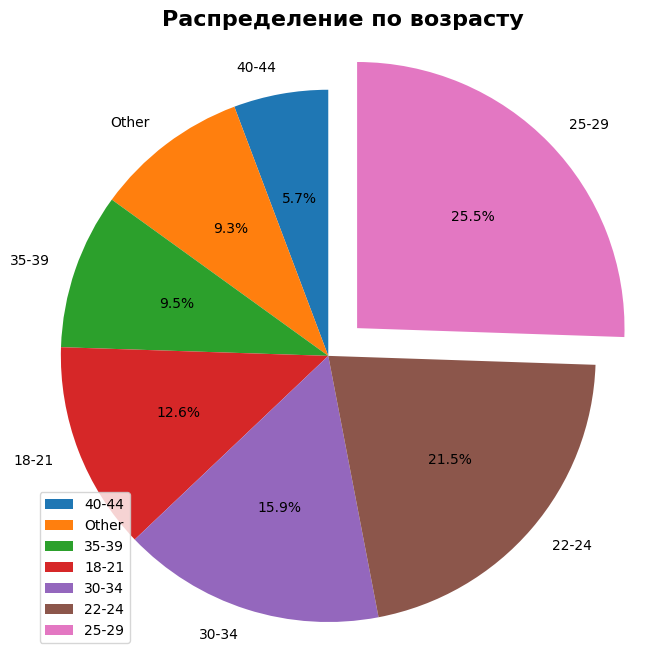

In [6]:
labels = [el for el in d]
info = [d[el] for el in d]

paired = sorted(zip(info,labels), key= lambda x: x[0])
info, labels = zip(*paired)

idx = np.argmax(info)
explode = np.zeros(len(info))  
explode[idx] = 0.15  

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    info, 
    labels=labels,
    autopct='%1.1f%%',  
    startangle=90,
    explode=explode 
)

ax.set_title('Распределение по возрасту', fontsize=16, fontweight='bold')
ax.axis('equal')

plt.legend()
plt.show()

### Задание 1.3. Столбцовая диаграмма
1. С помощью библиотеки `seaborn` построй столбцовую диаграмму (*Bar Plot*), отражающую популярность библиотек для визуализации данных.
2. Отфильтруй данные, оставив только ответы, относящиеся к библиотекам для визуализации данных.
3. Исключи из анализа категории с частотой встречаемости менее **500 наблюдений**.
4. Отсортируй библиотеки по убыванию популярности.
5. Используй горизонтальную ориентацию столбцов.
6. Применяй цветовую палитру `'colorblind'`.
7. Добавь информативный заголовок и поверни подписи на оси X на 30 градусов.

<img src="../misc/images/task_3.png" alt="task_3" width="600" height="400">

C:\Users\User\AppData\Local\Temp\ipykernel_14092\1412671155.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


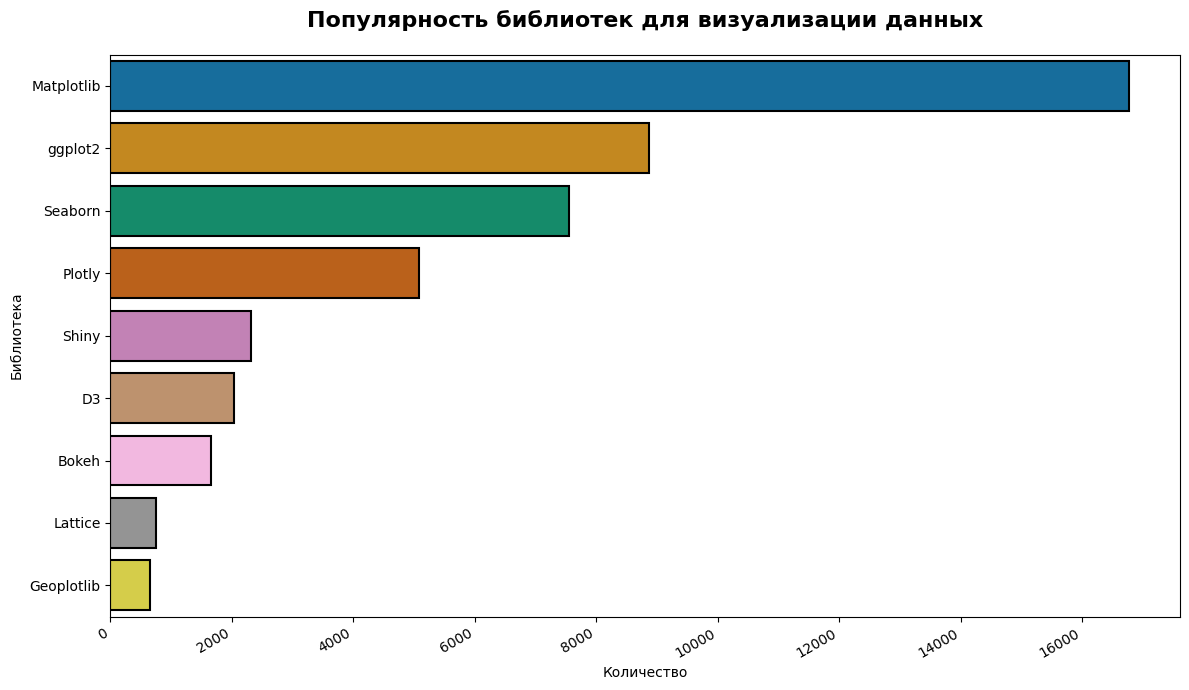

In [7]:
d = defaultdict(int)

libs = [
    'matplotlib',  
    'seaborn',     
    'plotly',        
    'bokeh',       
    'altair',      
    'pygal',        
    'ggplot',       
    'folium',       
    'geopandas',  
    'dash',         
    'holoviews',     
    'plotnine',
    'ggplot2',
    'shiny',
    'd3',
    'geoplotlib',
    'leeflet',
    'lattice'
]

for col in responses.columns:
    for el in responses[col]:
        if str(el).lower() in libs:
            d[el] += 1

labels = [lab for lab in d]

for lab in labels:
    if d[lab] < 500:
        del d[lab]

data = pd.DataFrame(
    {
        "Библиотека": list(d.keys()),
        "Количество": list(d.values())
    }
)

data = data.sort_values("Количество", ascending=False)



# Создаем фигуру большего размера для лучшей читаемости
plt.figure(figsize=(12, 7))

# Строим столбцовую диаграмму
bar_plot = sns.barplot(
    data=data,
    y='Библиотека',
    x='Количество',
    edgecolor='black',
    linewidth=1.5,
    palette='colorblind'
)

plt.title('Популярность библиотек для визуализации данных', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Задание 1.4. Диаграмма «ящик с усами»
1. С помощью библиотеки `seaborn` построй диаграмму **«ящик с усами» (box plot)**, отображающую распределение заработка по различным специальностям.
2. Исключи из анализа категории **студентов** и **неработающих**.
3. Зарплаты представлены категориями ("0-10000", "10-20000", "20-30000", ..., "500000+"). Преобразуй их в числовые значения через **соответствие категорий средним значениям диапазонов**: "0-10000" → 5000, "10-20000" → 15000, "20-30000" → 25000, "500000+" → 500000. Респондентов с неизвестным заработком исключи из анализа.
4. Отобрази по оси **Y** должности, а по оси **X** заработок в год.
5. Отсортируй специальности **по убыванию медианного значения заработка**. 
6. Ограничь диапазон оси **X** значением **до 500 000 $** в год.
7. Установи **шаг сетки по оси X** равным **50 000**.
8. Используй цветовую палитру `colorblind`.
9. Добавь **заголовок** и **подписи осей**.

<img src="../misc/images/task_4.png" alt="task_4" width="800" height="400">

In [8]:
change = responses.copy()

In [9]:
d = defaultdict()


def check_is_count(x):
    alf = '0123456789'
    for num in alf:
        if num in x:
            return True
    return False

for k in change["Q9"]:
    el = k
    if pd.notna(el) and check_is_count(el):
        el = el.replace(',','')
        el = el.replace('+','')
        el = [int(i) if len(i) > 3 else int(i + '000') for i in el.split('-')]
        el = sum(el)//len(el)
        d[k] = el
    else:
        d[k] = 0

change["Q9"] = change["Q9"].apply(lambda x: d[x])



In [10]:
median = change.groupby('Q6')['Q9'].median().sort_values(ascending=False)
del median['Student']
del median['Not employed']
positions = median.index.to_list()

C:\Users\User\AppData\Local\Temp\ipykernel_14092\1569857501.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=change,


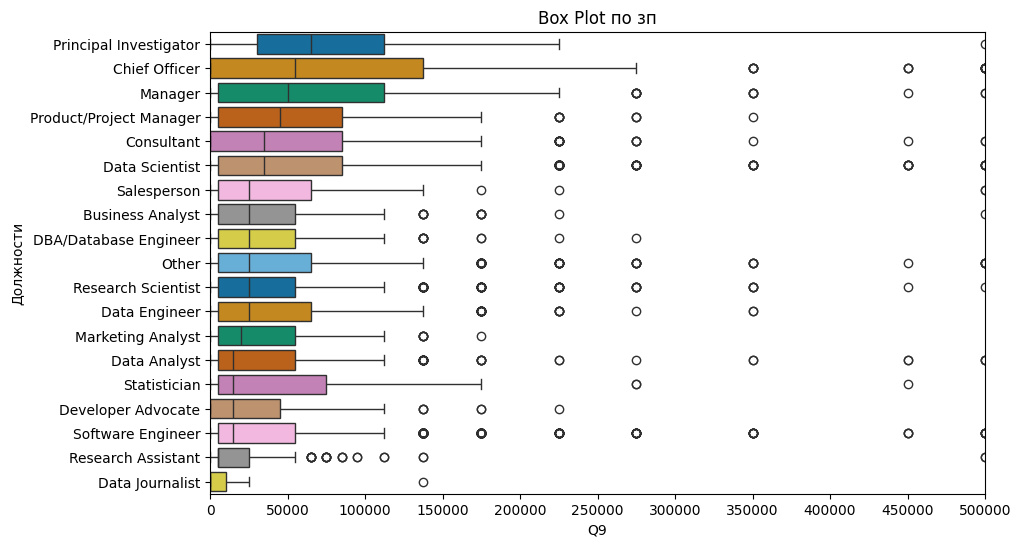

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=change,
            x='Q9', 
            y='Q6', 
            palette='colorblind',
            order=positions
)

plt.title("Box Plot по зп")
plt.ylabel("Должности")
plt.xlim(0, 500000)
plt.xticks(np.arange(0, 500001, 50000))
plt.show()

### Задание 1.5. Географическая карта респондентов
1. С помощью библиотеки `plotly` построй **интерактивную карту мира**, отображающую количество респондентов из каждой страны.
2. Для визуализации используй тип **choropleth map** (тепловая карта по регионам).
3. Закрась страны в зависимости от числа респондентов: чем больше значение, тем насыщеннее цвет.
4. Применяй цветовую шкалу `Viridis` для повышения читаемости.
5. Добавь **заголовок**, **легенду** и **подпись шкалы**, поясняющую интенсивность окрашивания.
6. Сделай карту интерактивной: при наведении курсора должны отображаться **названия стран** и **количество респондентов**.

<img src="../misc/images/task_5.png" alt="task_5" width="800" height="400">

In [12]:
d = defaultdict(int)

for el in change['Q3']:
    d[el] += 1

data = {
    'country': [],
    'values': []
}

for el in d:
    data['country'].append(el)
    data['values'].append(d[el])

df = pd.DataFrame(data)


In [13]:
fig = px.choropleth(
    df,
    locations='country', 
    locationmode='country names',
    color='values', 
    color_continuous_scale='Viridis',
    title='Choropleth Map',
    color_continuous_midpoint=None, 
    range_color=None, 
    labels={'values': 'Количество'}
)

fig.show()

C:\Users\User\AppData\Local\Temp\ipykernel_14092\74047250.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


### Задание 1.6. Диаграмма Sankey
1. Построй диаграмму Sankey, показывающую связь между уровнем образования и должностью респондентов.
2. Для основных степеней образования отобрази логическую иерархию:
   - Для респондентов с **Doctoral degree** покажи путь: `Bachelor's degree` → `Master's degree` → `Doctoral degree` → должность
   - Для респондентов с **Master's degree** покажи путь: `Bachelor's degree` → `Master's degree` → должность
   - Для респондентов с **Bachelor's degree** покажи связь: `Bachelor's degree` → должность
   - Для остальных уровней образования покажи прямую связь: уровень образования → должность
3. Примени разные контрастные цвета для разных типов узлов (степени бакалавра, магистра, доктора, остальные уровни образования, должности).
4. Толщина потоков должна отражать частоту переходов между узлами.

<img src="../misc/images/task_6.png" alt="task_6" width="800" height="600">


In [14]:
change.head()

,Time from Start to Finish (seconds),Q1,Q1_OTHER_TEXT,Q2,Q3,Q4,Q5,Q6,Q6_OTHER_TEXT,Q7,...,Q49_OTHER_TEXT,Q50_Part_1,Q50_Part_2,Q50_Part_3,Q50_Part_4,Q50_Part_5,Q50_Part_6,Q50_Part_7,Q50_Part_8,Q50_OTHER_TEXT
0,710,Female,-1,45-49,United States of America,Doctoral degree,Other,Consultant,-1,Other,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
1,434,Male,-1,30-34,Indonesia,Bachelor’s degree,Engineering (non-computer focused),Other,-2,Manufacturing/Fabrication,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2,718,Female,-1,30-34,United States of America,Master’s degree,"Computer science (software engineering, etc.)",Data Scientist,-1,I am a student,...,-1,NaN,Too time-consuming,NaN,NaN,NaN,NaN,NaN,NaN,-1
3,621,Male,-1,35-39,United States of America,Master’s degree,"Social sciences (anthropology, psychology, soc...",Not employed,-1,NaN,...,-1,NaN,NaN,Requires too much technical knowledge,NaN,Not enough incentives to share my work,NaN,NaN,NaN,-1
4,731,Male,-1,22-24,India,Master’s degree,Mathematics or statistics,Data Analyst,-1,I am a student,...,-1,NaN,Too time-consuming,NaN,NaN,Not enough incentives to share my work,NaN,NaN,NaN,-1


In [15]:
work = change["Q6"].value_counts().index.to_list()
degree = change["Q4"].value_counts().index.to_list()

all_nodes = work + degree

In [17]:
import pandas as pd
import plotly.graph_objects as go



# 1. Группируем и считаем частоту переходов
flow_data = (
    change.groupby(['Q4', 'Q6'], dropna=False)
    .size()
    .reset_index(name='count')
)

# 2. Создаем словари для маппинга меток в индексы
labels_list = []
label_to_idx = {}

def get_idx(label):
    if label not in label_to_idx:
        label_to_idx[label] = len(labels_list)
        labels_list.append(label)
    return label_to_idx[label]

# 3. Формируем массивы source, target, value
source = []
target = []
values = []

for _, row in flow_data.iterrows():
    src = get_idx(row['Q4'])
    tgt = get_idx(row['Q6'])
    source.append(src)
    target.append(tgt)
    values.append(row['count'])

# 4. Строим диаграмму
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels_list,
        color="blue"
    ),
    link=dict(
        source=source,
        target=target,
        value=values,
        color="rgba(0, 123, 255, 0.3)"
    )
)])

fig.update_layout(
    title_text="Переходы: Образование → Работа",
    font_size=12,
    height=600
)

fig.show()